In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("../data/processed/financial_fraud_feature_engineered.csv")
print(df.shape)

(1582354, 55)


In [5]:
#creating smaller sample from dataset
sample_df = df.sample(n=5000,random_state=42)
sample_df.shape

(5000, 55)

In [6]:
G = nx.Graph() #creating graph

In [8]:
for _, row in sample_df.iterrows():
    device = f"Device_{row['device_os_1']}"
    payment = f"Payment_{row['payment_type_1']}"
    fraud = f"Fraud_{row['fraud_bool']}"
    G.add_edge(device, payment)
    G.add_edge(payment, fraud)

In [9]:
print("Number of Nodes :", G.number_of_nodes())
print("Number of Edges :", G.number_of_edges())

Number of Nodes : 6
Number of Edges : 8


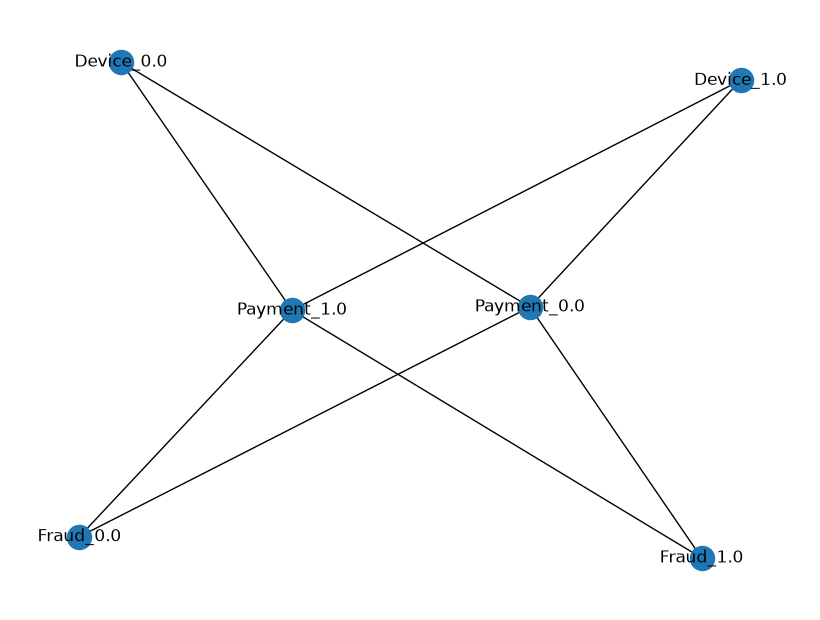

In [18]:
plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True)
plt.savefig("../reports/graph_network1.png", bbox_inches="tight")
plt.show()

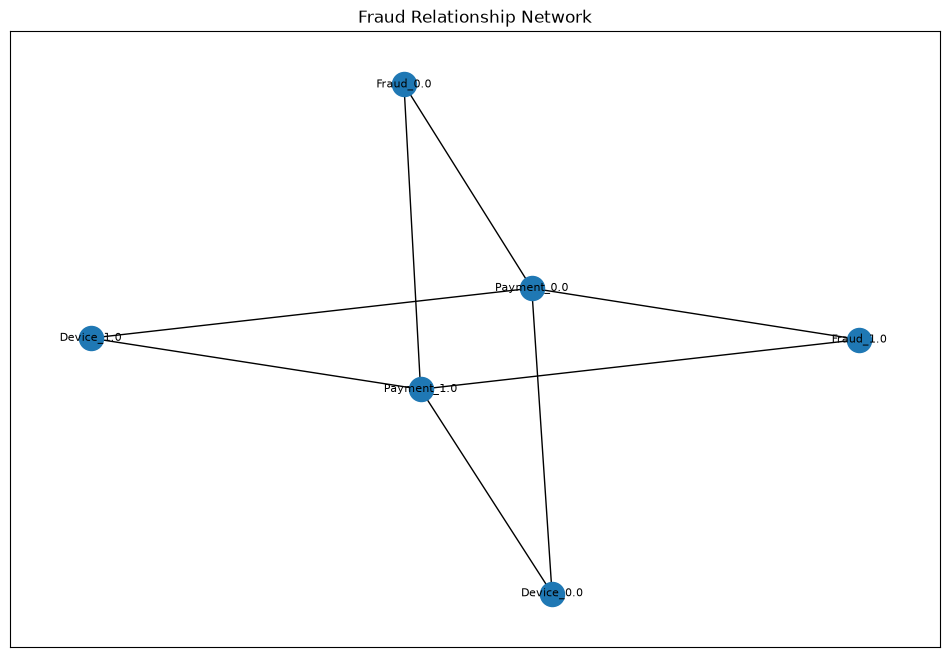

In [17]:
plt.figure(figsize=(12,8))
nx.draw_networkx(
    G,
    node_size=300,
    with_labels=True,
    font_size=8
)
plt.title("Fraud Relationship Network")
plt.savefig("../reports/graph_network.png", bbox_inches="tight")
plt.show()

In [19]:
centrality = nx.degree_centrality(G)
centrality_df = pd.DataFrame(
    centrality.items(),
    columns=["Node", "Centrality"]
)
centrality_df = centrality_df.sort_values(
    by="Centrality",
    ascending=False
)

centrality_df.head(10)

,Node,Centrality
1,Payment_0.0,0.8
3,Payment_1.0,0.8
0,Device_0.0,0.4
2,Fraud_1.0,0.4
4,Fraud_0.0,0.4
5,Device_1.0,0.4


In [20]:
centrality_df.to_csv("../data/processed/graph_centrality.csv",index=False)
print("Graph centrality saved.")

Graph centrality saved.


In [21]:
components = list(
    nx.connected_components(G)
)
print(
    "Connected Components:",
    len(components)
)

Connected Components: 1


In [22]:
density = nx.density(G)
print(
    "Network Density:",
    density
)

Network Density: 0.5333333333333333


In [24]:
import pickle
with open("../data/processed/fraud_network.gpickle", "wb") as f:
    pickle.dump(G, f)
print("Graph saved successfully.")

Graph saved successfully.


Summary

• Loaded feature engineered fraud dataset.
• Created a fraud relationship network using device, payment, and fraud indicators.
• Built a graph using NetworkX.
• Calculated node degree centrality.
• Identified highly connected nodes.
• Computed connected components and network density.
• Visualized the fraud network structure.
• Saved graph analytics results and network file.